                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Train Shape: (35000, 200)
Validation Shape: (7500, 200)
Test Shape: (7500, 200)


C:\Users\23adsb66\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - accuracy: 0.5762 - loss: 0.6549 - val_accuracy: 0.6403 - val_loss: 0.5780
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 39s 67ms/step - accuracy: 0.7632 - loss: 0.5083 - val_accuracy: 0.8167 - val_loss: 0.4564
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 39s 71ms/step - accuracy: 0.8015 - loss: 0.4815 - val_accuracy: 0.8161 - val_loss: 0.4498
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.7207 - loss: 0.5335 - val_accuracy: 0.6012 - val_loss: 0.6110
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.7785 - loss: 0.4880 - val_accuracy: 0.7968 - val_loss: 0.5015


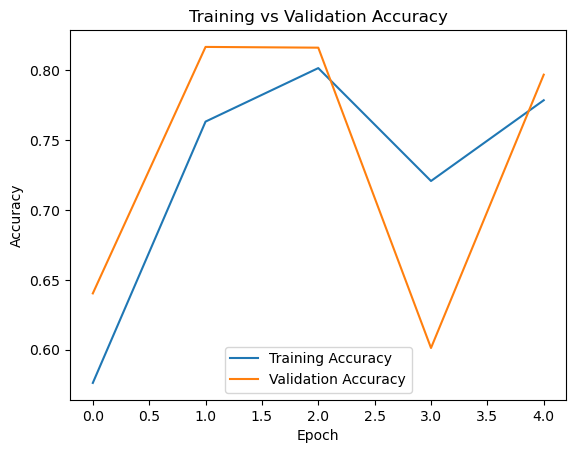

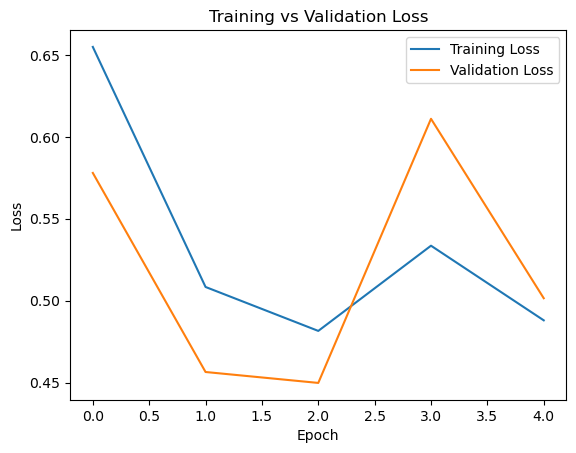

235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8096 - loss: 0.4774
Final Test Loss: 0.4773994982242584
Final Test Accuracy: 0.8095999956130981
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Review: This movie was absolutely fantastic! I loved it.
Prediction: Positive


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
data = pd.read_csv(r"C:\Users\23adsb66\Downloads\archive\IMDB Dataset.csv")
print(data.head())
data['sentiment'] = data['sentiment'].map({'positive':1, 'negative':0})
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(data['review'])
X = tokenizer.texts_to_sequences(data['review'])
y = data['sentiment']
max_length = 200
X = pad_sequences(X, maxlen=max_length, padding='post')
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Train Shape:", X_train.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=max_length))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
loss, accuracy = model.evaluate(X_test, y_test)
print("Final Test Loss:", loss)
print("Final Test Accuracy:", accuracy)
sample_review = "This movie was absolutely fantastic! I loved it."
seq = tokenizer.texts_to_sequences([sample_review])
padded = pad_sequences(seq, maxlen=max_length, padding='post')
prediction = model.predict(padded)
print("Review:", sample_review)
print("Prediction:", "Positive" if prediction[0][0] > 0.5 else "Negative")